In [ ]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.0 MB/s eta 0:00:00


# ***Hidden Markov Model (HMM) for classification***

In [ ]:
!pip install ucimlrepo

# ***`Ionosphere Dataset`***

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
ionosphere = fetch_ucirepo(id=52)

# data (as pandas dataframes)
X = ionosphere.data.features
y = ionosphere.data.targets



# ***Importing important libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ***GaussianHMM without parameter tuning***

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

from hmmlearn import hmm
classifier = hmm.GaussianHMM()
classifier.fit(X_train)

# To Remove Warnings
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
# 2. Suppress hmmlearn warnings and other general runtime warnings
warnings.filterwarnings("ignore")

y_pred = classifier.predict(X_test)

# Convert y_test labels to numerical format
y_test_numeric = y_test.replace({'g': 0, 'b': 1}) # Assuming 'g' maps to 0 and 'b' to 1 based on the error message


# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_numeric, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test_numeric, y_pred))

Confusion Matrix:
[[42  0]
 [29  0]]
--------------------------------------------------
--------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        42
           1       0.00      0.00      0.00        29

    accuracy                           0.59        71
   macro avg       0.30      0.50      0.37        71
weighted avg       0.35      0.59      0.44        71



# ***GaussianHMM with parameter tuning***

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)


from hmmlearn import hmm
classifier = hmm.GaussianHMM(
    n_components=2,        # start with 2 for binary
    covariance_type="full",
    n_iter=1000,
    tol=1e-3,
    random_state=42,
    init_params="stmc",  # update startprob, transmat, means, covars
    params="stmc"        # allow these to be updated during training
)
classifier.fit(X_train)

y_pred = classifier.predict(X_test)

# Convert y_test labels to numerical format
y_test_numeric = y_test.replace({'g': 0, 'b': 1}) # Assuming 'g' maps to 0 and 'b' to 1 based on the error message


# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
accuracy_g = round(accuracy_score(y_test_numeric, y_pred),2)

print("Confusion Matrix:")
print(confusion_matrix(y_test_numeric, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test_numeric, y_pred))

Confusion Matrix:
[[40  4]
 [ 5 22]]
--------------------------------------------------
--------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        44
           1       0.85      0.81      0.83        27

    accuracy                           0.87        71
   macro avg       0.87      0.86      0.86        71
weighted avg       0.87      0.87      0.87        71



# **`Completed`**

# **Construct a Deep Learning model using Convolutional Neural Network (CNN) for classification of Data Set CIFAR-10**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np

# Set a seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def create_cnn_model(input_shape, num_classes):
    """
    Defines a standard Convolutional Neural Network architecture suitable for CIFAR-10 (32x32x3).
    """
    model = Sequential([
        # Input Layer: 32x32 images with 3 color channels (RGB)
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((2, 2)),

        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        Flatten(),
        Dense(256, activation='relu'),
        # Dropout helps prevent overfitting, common in complex image datasets
        Dropout(0.5),

        # Output layer for 10 classes (Softmax gives probabilities)
        Dense(num_classes, activation='softmax')
    ], name='CIFAR10_CNN')

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def analyze_cifar10():
    """Loads, preprocesses, trains, and evaluates the CNN on the CIFAR-10 dataset."""
    print("====================================================")
    print("         Starting Analysis on CIFAR-10 (32x32x3)")
    print("====================================================")

    # --- 1. Load and Preprocess Data ---
    # CIFAR-10 is a built-in dataset in Keras
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    # Normalize pixel values to be between 0 and 1
    # Images are 32x32 pixels with 3 color channels (RGB)
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # Convert labels (0 to 9) to one-hot encoding (required for categorical_crossentropy)
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    # --- 2. Create and Train Model ---

    input_shape = x_train.shape[1:] # (32, 32, 3)
    model = create_cnn_model(input_shape, num_classes)
    model.summary()

    # Train the model
    print("\n--- Training Model for CIFAR-10 ---")
    history = model.fit(x_train, y_train_one_hot,
    batch_size=4,
    epochs=20, # Increased epochs for better CIFAR-10 results
    validation_split=0.1,
    verbose=1)

    # --- 3. Evaluate Model ---
    print("\n--- Evaluating Model on CIFAR-10 Test Set ---")
    loss, accuracy = model.evaluate(x_test, y_test_one_hot, verbose=0)

    print(f"\n[CIFAR-10 Results] Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
    print("====================================================")


if __name__ == '__main__':
    analyze_cifar10()


         Starting Analysis on CIFAR-10 (32x32x3)


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)


--- Training Model for CIFAR-10 ---
Epoch 1/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.3346 - loss: 1.7952 - val_accuracy: 0.5718 - val_loss: 1.2028
Epoch 2/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.5545 - loss: 1.2525 - val_accuracy: 0.6210 - val_loss: 1.0770
Epoch 3/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.6044 - loss: 1.1204 - val_accuracy: 0.6456 - val_loss: 1.0136
Epoch 4/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.6358 - loss: 1.0411 - val_accuracy: 0.6658 - val_loss: 0.9762
Epoch 5/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.6497 - loss: 1.0004 - val_accuracy: 0.6526 - val_loss: 0.9996
Epoch 6/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step - accuracy: 0.6713 - loss: 0.9571 - val_accuracy: 0.6692 - val_loss: 0.9795
Epoch 7/20
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.6774 - loss: 0.9289 - val_accuracy: 0.6786 - val_loss: 0.9390
Epoch 8/20
11250/11250 ━━━━━━━━━

# **Construct a Deep Learning model using Convolutional Neural Network (CNN) for classification of Data Set MNIST**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator # New Import
import numpy as np

# Set a seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

def create_cnn_model(input_shape, num_classes):
    """
    Defines a standard Convolutional Neural Network architecture suitable for image classification.
    """
    model = Sequential([
        # Initial Convolutional Block (Input shape adapts based on dataset)
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((2, 2)),

        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Third Convolutional Block (Added depth helps CIFAR-10, beneficial for MNIST too)
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        Flatten(),
        Dense(256, activation='relu'),
        # Dropout helps prevent overfitting, common in complex image datasets
        Dropout(0.5),

        # Output layer for 10 classes (Softmax gives probabilities)
        Dense(num_classes, activation='softmax')
    ], name='General_CNN')

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def analyze_mnist():
    """Loads, preprocesses, trains, and evaluates the CNN on the MNIST dataset."""
    print("\n\n====================================================")
    print("           Starting Analysis on MNIST (28x28x1)")
    print("====================================================")

    # --- 1. Load and Preprocess Data ---
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # --- Data Size: Using FULL dataset (60,000 training samples, 10,000 test samples) ---

    print(f"--- Using FULL MNIST dataset: {len(x_train)} training samples and {len(x_test)} test samples ---")
    # --------------------------------------------------------

    # Reshape input to (samples, 28, 28, 1) and normalize
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    # Convert labels to one-hot encoding
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    # --- 2. Create and Train Model ---

    input_shape = x_train.shape[1:] # (28, 28, 1)
    model = create_cnn_model(input_shape, num_classes)

    # Train the model
    print("\n--- Training Model for MNIST ---")
    model.fit(x_train, y_train_one_hot,
    batch_size=4,
    epochs=10,
    validation_split=0.1,
    verbose=1)

    # --- 3. Evaluate Model ---
    print("\n--- Evaluating Model on MNIST Test Set ---")
    loss, accuracy = model.evaluate(x_test, y_test_one_hot, verbose=0)

    print(f"\n[MNIST Results] Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
    print("====================================================")


if __name__ == '__main__':
    analyze_mnist()




           Starting Analysis on MNIST (28x28x1)
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Using FULL MNIST dataset: 60000 training samples and 10000 test samples ---

--- Training Model for MNIST ---
Epoch 1/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - accuracy: 0.9045 - loss: 0.2973 - val_accuracy: 0.9885 - val_loss: 0.0366
Epoch 2/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9797 - loss: 0.0723 - val_accuracy: 0.9888 - val_loss: 0.0380
Epoch 3/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9853 - loss: 0.0535 - val_accuracy: 0.9890 - val_loss: 0.0486
Epoch 4/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9884 - loss: 0.0431 - val_accuracy: 0.9902 - val_loss: 0.0585
Epoch 5/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9883 - loss: 0.0440 - val_accuracy: 0.9823 - val_loss: 0.0918
Epoch 6/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.9887 - loss: 0.0439 - val_accuracy: 0.9905 - val_

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    Input, LSTM, Reshape, Concatenate, AveragePooling2D, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import numpy as np
import time

# Set a seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Global Training Constants
GLOBAL_BATCH_SIZE = 4
GLOBAL_EPOCHS = 10

# ====================================================================
# 1. MODEL DEFINITIONS
# ====================================================================

def create_custom_cnn(input_shape, num_classes):
    """Defines the custom CNN architecture."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name='Custom_CNN')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_vgg16_transfer_model(input_shape, num_classes):
    """VGG16 using Transfer Learning (frozen base)."""
    # VGG16 expects at least 32x32 input. MNIST 28x28 is handled in preprocessing.
    vgg_base = VGG16(weights='imagenet',
                     include_top=False,
                     input_shape=input_shape)
    vgg_base.trainable = False # Freeze the base

    x = Flatten(name='flatten_new')(vgg_base.output)
    x = Dense(256, activation='relu', name='fc1_new')(x)
    x = Dropout(0.5, name='dropout_new')(x)
    output = Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=vgg_base.input, outputs=output, name='VGG16_Transfer')

    # --- Already Compiled, but leaving here for clarity ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_lstm_rnn_model(input_shape, num_classes):
    """
    Recurrent Neural Network (LSTM) model.
    It processes the image as a sequence of pixel rows.
    """
    # Input shape: (Height, Width, Channels)

    height, width, channels = input_shape

    model = Sequential([
        # Reshape to (Height, Width * Channels)
        Reshape((height, width * channels), input_shape=input_shape),

        # LSTM layer to process the sequence
        LSTM(128, return_sequences=False),

        # Classification head
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name='LSTM_RNN')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_alexnet_model(input_shape, num_classes):
    """Simplified AlexNet-like architecture for smaller images."""
    inputs = Input(shape=input_shape)

    # 1. First Conv layer (smaller filter, large strides)
    x = Conv2D(48, (5, 5), strides=(1, 1), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = BatchNormalization()(x)

    # 2. Second Conv layer
    x = Conv2D(128, (5, 5), activation='relu', padding='same')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = BatchNormalization()(x)

    # 3. and 4. Three consecutive Conv layers
    x = Conv2D(192, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(192, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    # 5. Fully connected layers
    x = Flatten()(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=output, name='AlexNet_Like')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def inception_module(x, f1x1, f3x3_reduce, f3x3, f5x5_reduce, f5x5, pool_proj):
    """Simplified Inception (GoogLeNet) module."""
    # 1x1 branch
    branch1x1 = Conv2D(f1x1, (1, 1), padding='same', activation='relu')(x)

    # 1x1 followed by 3x3 branch
    branch5x5 = Conv2D(f3x3_reduce, (1, 1), padding='same', activation='relu')(x)
    branch5x5 = Conv2D(f3x3, (3, 3), padding='same', activation='relu')(branch5x5)

    # 1x1 followed by 5x5 branch
    branch3x3 = Conv2D(f5x5_reduce, (1, 1), padding='same', activation='relu')(x)
    branch3x3 = Conv2D(f5x5, (5, 5), padding='same', activation='relu')(branch3x3)

    # Pooling branch
    branch_pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = Conv2D(pool_proj, (1, 1), padding='same', activation='relu')(branch_pool)

    # Concatenate all branches
    return Concatenate(axis=-1)([branch1x1, branch5x5, branch3x3, branch_pool])

def create_googlenet_model(input_shape, num_classes):
    """Simplified GoogLeNet (Inception V1) architecture."""
    inputs = Input(shape=input_shape)

    # Initial Stem
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)

    # Simplified Inception Blocks
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 64, 64)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    x = inception_module(x, 160, 112, 224, 24, 64, 64)

    # Classification Head
    x = AveragePooling2D((8, 8), padding='valid')(x) # Global average pooling
    x = Flatten()(x)
    x = Dropout(0.4)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=output, name='GoogLeNet_Like')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ====================================================================
# 2. DATA LOADING & PREPROCESSING PIPELINE
# ====================================================================

def load_and_preprocess_cifar10():
    """Load CIFAR-10 data, normalize, and one-hot encode."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)
    input_shape = x_train.shape[1:]
    return (x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes)

def load_and_preprocess_mnist():
    """Load MNIST data, convert to 3 channels and resize to 32x32 for VGG/AlexNet/GoogLeNet."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # 1. Initial Reshape and Normalize
    # Reshape to (samples, 28, 28, 1) and normalize to 0-1
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    # 2. MANDATORY RESIZE: Scale images up to 32x32
    # VGG16 requires a minimum spatial size of 32x32.
    x_train = tf.image.resize(x_train, [32, 32]).numpy()
    x_test = tf.image.resize(x_test, [32, 32]).numpy()

    # 3. MANDATORY CHANNEL REPLICATION: Replicate the single channel 3 times
    # VGG16 requires 3 color channels (RGB).
    x_train = np.repeat(x_train, 3, axis=-1)
    x_test = np.repeat(x_test, 3, axis=-1)

    # Convert labels to one-hot encoding
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    # Final input_shape is correctly (32, 32, 3)
    input_shape = x_train.shape[1:]

    return (x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes)

# ====================================================================
# 3. COMPARISON PIPELINE
# ====================================================================

def compare_models(dataset_name, data_loader_func):
    """Runs the comparison between all models on a given dataset."""
    print(f"\n====================================================")
    print(f"       Starting Comparison on {dataset_name}")
    print(f"====================================================")

    # 1. Load Data
    x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes = data_loader_func()
    print(f"--- Using FULL {dataset_name} dataset: {len(x_train)} training samples and {len(x_test)} test samples ---")

    all_results = {}

    # Initialize class_names here for use in the final output packaging
    if dataset_name == "CIFAR-10":
        # CIFAR-10 class names (0-9)
        class_names = [f"Class {i}" for i in range(10)]
    elif dataset_name == "MNIST":
        # MNIST class names (0-9)
        class_names = [str(i) for i in range(10)]
    else:
        class_names = [f"Unknown {i}" for i in range(num_classes)]

    # Data Augmentation Setup (Only used by Custom CNN on CIFAR-10)
    datagen = ImageDataGenerator(
        rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True
    )
    if dataset_name == "CIFAR-10":
        datagen.fit(x_train)

    # Dictionary of all models to compare
    model_creators = {
        # 'Custom CNN': create_custom_cnn, # Removed Custom CNN as requested
        'VGG16 Transfer': create_vgg16_transfer_model,
        'LSTM RNN': create_lstm_rnn_model,
        'AlexNet-like': create_alexnet_model,
        'GoogLeNet-like': create_googlenet_model
    }

    # 2. Train and Evaluate all models
    for model_name, creator_func in model_creators.items():
        print(f"\n--- Training {model_name} for {dataset_name} ({GLOBAL_EPOCHS} epochs, Batch Size {GLOBAL_BATCH_SIZE}) ---")

        start_time = time.time()

        model = creator_func(input_shape, num_classes)

        # --- REMOVED THE FAILING CHECK ---
        # if model.optimizer is None:
        #    model.compile(...)
        # The compile step is now guaranteed to be inside each model creation function.

        # Print summary for the first model of each type (VGG16 is a good choice for summary)
        if model_name in ['VGG16 Transfer']:
            model.summary()

        # Fit the model
        if dataset_name == "CIFAR-10" and model_name == 'Custom CNN':
            # This block is now skipped since Custom CNN is removed.
            history = model.fit(datagen.flow(x_train, y_train_one_hot, batch_size=GLOBAL_BATCH_SIZE),
                                steps_per_epoch=len(x_train) // GLOBAL_BATCH_SIZE,
                                epochs=GLOBAL_EPOCHS,
                                validation_data=(x_test, y_test_one_hot),
                                verbose=1)
        else:
            # Simple fit for all models
            history = model.fit(x_train, y_train_one_hot,
                                batch_size=GLOBAL_BATCH_SIZE,
                                epochs=GLOBAL_EPOCHS,
                                validation_split=0.1, # Use validation split instead of full test set
                                verbose=1)

        # Evaluate Model
        loss, accuracy = model.evaluate(x_test, y_test_one_hot, verbose=0)
        y_pred_probs = model.predict(x_test, verbose=0)
        end_time = time.time()

        all_results[model_name] = {
            'Loss': loss,
            'Accuracy': accuracy,
            'Time': end_time - start_time,
            'History': history, # <-- Saving the training history object
            'y_pred_probs': y_pred_probs # <-- Saving the prediction probabilities
        }
        del model # Clear model from memory

    # # 3. Display Comparison
    # print("\n" + "="*70)
    # print(f"      FINAL PERFORMANCE COMPARISON: {dataset_name} (Epochs={GLOBAL_EPOCHS}, Batch Size={GLOBAL_BATCH_SIZE})")
    # print("="*70)
    # print(f"{'Model':<20} | {'Test Loss':<10} | {'Test Accuracy':<15} | {'Train Time (s)':<15}")
    # print("-" * 70)
    # for model_name, metrics in results.items():
    #     print(f"{model_name:<20} | {metrics['Loss']:.4f} | {metrics['Accuracy']:.4f} | {metrics['Time']:.2f}")
    # print("="*70)

    # ====================================================================
# 3. COMPARISON PIPELINE (REQUIRED SECTION FOR DATA EXPORT)
# ====================================================================

# ... (Previous code within compare_models function) ...

    # 3. Display Comparison and Find Best Model
    print("\n" + "="*70)
    print(f"       FINAL PERFORMANCE COMPARISON: {dataset_name} (Epochs={GLOBAL_EPOCHS}, Batch Size={GLOBAL_BATCH_SIZE})")
    print("="*70)
    print(f"{'Model':<20} | {'Test Loss':<10} | {'Test Accuracy':<15} | {'Train Time (s)':<15}")
    print("-" * 70)

    best_accuracy = -1
    best_model_name = ""
    best_model_data = {}

    for model_name, metrics in all_results.items():
        print(f"{model_name:<20} | {metrics['Loss']:.4f} | {metrics['Accuracy']:.4f} | {metrics['Time']:.2f}")

        # Track the single best model based on Test Accuracy
        if metrics['Accuracy'] > best_accuracy:
            best_accuracy = metrics['Accuracy']
            best_model_name = model_name
            best_model_data = {
                'name': model_name,
                'history': metrics['History'],
                'y_pred_probs': metrics['y_pred_probs'],
                'y_test_one_hot': y_test_one_hot,
                'class_names': class_names,
                'num_classes': num_classes,
                'dataset_name': dataset_name
            }

    print("="*70)
    print(f"Best Model for {dataset_name}: {best_model_name} (Accuracy: {best_accuracy:.4f})")
    print("="*70)

    # Return the data for the best model for subsequent plotting
    return best_model_data

# ... (rest of the script) ...


if __name__ == '__main__':
    # Run the comparison for both datasets
    cifar_best_data = compare_models("CIFAR-10", load_and_preprocess_cifar10)
    # compare_models("MNIST", load_and_preprocess_mnist)



       Starting Comparison on CIFAR-10
--- Using FULL CIFAR-10 dataset: 50000 training samples and 10000 test samples ---

--- Training VGG16 Transfer for CIFAR-10 (10 epochs, Batch Size 4) ---


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_new (Flatten)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_new (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_new (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 63s 5ms/step - accuracy: 0.4230 - loss: 1.6380 - val_accuracy: 0.5606 - val_loss: 1.2669
Epoch 2/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5203 - loss: 1.3805 - val_accuracy: 0.5696 - val_loss: 1.2371
Epoch 3/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.5352 - loss: 1.3311 - val_accuracy: 0.5856 - val_loss: 1.1970
Epoch 4/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5430 - loss: 1.3003 - val_accuracy: 0.5936 - val_loss: 1.1957
Epoch 5/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 83s 5ms/step - accuracy: 0.5527 - loss: 1.2866 - val_accuracy: 0.5880 - val_loss: 1.1897
Epoch 6/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5575 - loss: 1.2714 - val_accuracy: 0.5954 - val_loss: 1.1712
Epoch 7/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.5653 - loss: 1.2492 - val_accuracy: 0.5990 - val_loss: 1.1787
Epoch 8/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 59s 5ms/step - accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 75s 7ms/step - accuracy: 0.2028 - loss: 2.1240 - val_accuracy: 0.3588 - val_loss: 1.7435
Epoch 2/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 71s 6ms/step - accuracy: 0.3524 - loss: 1.7583 - val_accuracy: 0.3960 - val_loss: 1.6152
Epoch 3/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 73s 6ms/step - accuracy: 0.3853 - loss: 1.6725 - val_accuracy: 0.4164 - val_loss: 1.5894
Epoch 4/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 75s 7ms/step - accuracy: 0.4094 - loss: 1.6113 - val_accuracy: 0.4420 - val_loss: 1.5179
Epoch 5/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - accuracy: 0.4237 - loss: 1.5664 - val_accuracy: 0.4566 - val_loss: 1.4717
Epoch 6/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.4429 - loss: 1.5239 - val_accuracy: 0.4746 - val_loss: 1.4347
Epoch 7/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.4570 - loss: 1.4895 - val_accuracy: 0.4808 - val_loss: 1.4278
Epoch 8/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings

# Suppress warnings related to Matplotlib/Seaborn
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# ====================================================================
# VISUALIZATION FUNCTIONS
# ====================================================================

def plot_training_history(history, dataset_name, model_name):
    """Generates the training & loss generation curves."""
    plt.figure(figsize=(12, 4))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(f'{dataset_name} - {model_name} Loss Curve')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{dataset_name} - {model_name} Accuracy Curve')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(f"--- Generated Training & Loss/Accuracy curves for {model_name} on {dataset_name} ---")


def plot_confusion_matrix_heatmap(y_true_one_hot, y_pred_probs, class_names, dataset_name, model_name):
    """Generates the confusion matrix heatmap."""
    # Convert one-hot encoded arrays back to single label indices
    y_true_labels = np.argmax(y_true_one_hot, axis=1)
    y_pred_labels = np.argmax(y_pred_probs, axis=1) # Use predicted probabilities

    cm = confusion_matrix(y_true_labels, y_pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{dataset_name} - {model_name} Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print(f"--- Generated Confusion Matrix heatmap for {model_name} on {dataset_name} ---")


def plot_roc_curve_multiclass(y_true_one_hot, y_pred_probs, dataset_name, model_name, num_classes):
    """Generates the multiclass ROC curve (One-vs-Rest)."""
    plt.figure(figsize=(8, 6))

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(num_classes):
        # Calculate ROC curve and AUC for each class vs. the rest
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(fpr[i], tpr[i],
                 label=f'ROC curve (Class {i}, AUC = {roc_auc[i]:.2f})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{dataset_name} - {model_name} ROC Curves (One-vs-Rest)')
    plt.legend(loc="lower right", fontsize='small')
    plt.show()
    print(f"--- Generated ROC curve and AUC for {model_name} on {dataset_name} ---")


if __name__ == '__main__':
    # NOTE: You must run dl_training_comparison.py first, and ensure the
    # 'cifar_best_data' and 'mnist_best_data' variables are available in this environment
    # (e.g., if you copy-paste the output dictionary or save it to a file).

    # Placeholder for data structure (Assuming data is loaded or available here)
    try:
        if 'cifar_best_data' not in globals() or 'mnist_best_data' not in globals():
            print("ERROR: Please run dl_training_comparison.py first to generate 'cifar_best_data' and 'mnist_best_data'.")
            exit()
    except NameError:
        print("ERROR: Please run dl_training_comparison.py first to generate 'cifar_best_data' and 'mnist_best_data'.")
        exit()


    # 1. Generate plots for CIFAR-10's BEST model
    cifar_best = globals().get('cifar_best_data')
    if cifar_best:
        print("\n" + "="*50)
        print("   VISUALIZING BEST CIFAR-10 MODEL")
        print("="*50)

        plot_training_history(cifar_best['history'], cifar_best['dataset_name'], cifar_best['name'])

        plot_confusion_matrix_heatmap(
            cifar_best['y_test_one_hot'],
            cifar_best['y_pred_probs'],
            cifar_best['class_names'],
            cifar_best['dataset_name'],
            cifar_best['name']
        )

        plot_roc_curve_multiclass(
            cifar_best['y_test_one_hot'],
            cifar_best['y_pred_probs'],
            cifar_best['dataset_name'],
            cifar_best['name'],
            cifar_best['num_classes']
        )

    # 2. Generate plots for MNIST's BEST model
    # mnist_best = globals().get('mnist_best_data')
    # if mnist_best:
    #     print("\n" + "="*50)
    #     print("   VISUALIZING BEST MNIST MODEL")
    #     print("="*50)

    #     plot_training_history(mnist_best['history'], mnist_best['dataset_name'], mnist_best['name'])

    #     plot_confusion_matrix_heatmap(
    #         mnist_best['y_test_one_hot'],
    #         mnist_best['y_pred_probs'],
    #         mnist_best['class_names'],
    #         mnist_best['dataset_name'],
    #         mnist_best['name']
    #     )

    #     plot_roc_curve_multiclass(
    #         mnist_best['y_test_one_hot'],
    #         mnist_best['y_pred_probs'],
    #         mnist_best['dataset_name'],
    #         mnist_best['name'],
    #         mnist_best['num_classes']
    #     )


ERROR: Please run dl_training_comparison.py first to generate 'cifar_best_data' and 'mnist_best_data'.


# =========================================================================================

# **Experiment with the following Deep Learning models on the above the two datasets (given in Question No. 2) and show the performance comparison among the models along with that of CNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    Input, LSTM, Reshape, Concatenate, AveragePooling2D, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import numpy as np
import time

# Set a seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Global Training Constants
GLOBAL_BATCH_SIZE = 4
GLOBAL_EPOCHS = 10

# ====================================================================
# 1. MODEL DEFINITIONS
# ====================================================================

def create_custom_cnn(input_shape, num_classes):
    """Defines the custom CNN architecture."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name='Custom_CNN')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_vgg16_transfer_model(input_shape, num_classes):
    """VGG16 using Transfer Learning (frozen base)."""
    # VGG16 expects at least 32x32 input. MNIST 28x28 is handled in preprocessing.
    vgg_base = VGG16(weights='imagenet',
                     include_top=False,
                     input_shape=input_shape)
    vgg_base.trainable = False # Freeze the base

    x = Flatten(name='flatten_new')(vgg_base.output)
    x = Dense(256, activation='relu', name='fc1_new')(x)
    x = Dropout(0.5, name='dropout_new')(x)
    output = Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=vgg_base.input, outputs=output, name='VGG16_Transfer')

    # --- Already Compiled, but leaving here for clarity ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_lstm_rnn_model(input_shape, num_classes):
    """
    Recurrent Neural Network (LSTM) model.
    It processes the image as a sequence of pixel rows.
    """
    # Input shape: (Height, Width, Channels)

    height, width, channels = input_shape

    model = Sequential([
        # Reshape to (Height, Width * Channels)
        Reshape((height, width * channels), input_shape=input_shape),

        # LSTM layer to process the sequence
        LSTM(128, return_sequences=False),

        # Classification head
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name='LSTM_RNN')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_alexnet_model(input_shape, num_classes):
    """Simplified AlexNet-like architecture for smaller images."""
    inputs = Input(shape=input_shape)

    # 1. First Conv layer (smaller filter, large strides)
    x = Conv2D(48, (5, 5), strides=(1, 1), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = BatchNormalization()(x)

    # 2. Second Conv layer
    x = Conv2D(128, (5, 5), activation='relu', padding='same')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = BatchNormalization()(x)

    # 3. and 4. Three consecutive Conv layers
    x = Conv2D(192, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(192, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    # 5. Fully connected layers
    x = Flatten()(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)

    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=output, name='AlexNet_Like')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def inception_module(x, f1x1, f3x3_reduce, f3x3, f5x5_reduce, f5x5, pool_proj):
    """Simplified Inception (GoogLeNet) module."""
    # 1x1 branch
    branch1x1 = Conv2D(f1x1, (1, 1), padding='same', activation='relu')(x)

    # 1x1 followed by 3x3 branch
    branch5x5 = Conv2D(f3x3_reduce, (1, 1), padding='same', activation='relu')(x)
    branch5x5 = Conv2D(f3x3, (3, 3), padding='same', activation='relu')(branch5x5)

    # 1x1 followed by 5x5 branch
    branch3x3 = Conv2D(f5x5_reduce, (1, 1), padding='same', activation='relu')(x)
    branch3x3 = Conv2D(f5x5, (5, 5), padding='same', activation='relu')(branch3x3)

    # Pooling branch
    branch_pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = Conv2D(pool_proj, (1, 1), padding='same', activation='relu')(branch_pool)

    # Concatenate all branches
    return Concatenate(axis=-1)([branch1x1, branch5x5, branch3x3, branch_pool])

def create_googlenet_model(input_shape, num_classes):
    """Simplified GoogLeNet (Inception V1) architecture."""
    inputs = Input(shape=input_shape)

    # Initial Stem
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = BatchNormalization()(x)

    # Simplified Inception Blocks
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 64, 64)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    x = inception_module(x, 160, 112, 224, 24, 64, 64)

    # Classification Head
    x = AveragePooling2D((8, 8), padding='valid')(x) # Global average pooling
    x = Flatten()(x)
    x = Dropout(0.4)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=output, name='GoogLeNet_Like')

    # --- FIX: Ensure compilation here ---
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ====================================================================
# 2. DATA LOADING & PREPROCESSING PIPELINE
# ====================================================================

def load_and_preprocess_cifar10():
    """Load CIFAR-10 data, normalize, and one-hot encode."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)
    input_shape = x_train.shape[1:]
    return (x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes)

def load_and_preprocess_mnist():
    """Load MNIST data, convert to 3 channels and resize to 32x32 for VGG/AlexNet/GoogLeNet."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # 1. Initial Reshape and Normalize
    # Reshape to (samples, 28, 28, 1) and normalize to 0-1
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    # 2. MANDATORY RESIZE: Scale images up to 32x32
    # VGG16 requires a minimum spatial size of 32x32.
    x_train = tf.image.resize(x_train, [32, 32]).numpy()
    x_test = tf.image.resize(x_test, [32, 32]).numpy()

    # 3. MANDATORY CHANNEL REPLICATION: Replicate the single channel 3 times
    # VGG16 requires 3 color channels (RGB).
    x_train = np.repeat(x_train, 3, axis=-1)
    x_test = np.repeat(x_test, 3, axis=-1)

    # Convert labels to one-hot encoding
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    # Final input_shape is correctly (32, 32, 3)
    input_shape = x_train.shape[1:]

    return (x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes)

# ====================================================================
# 3. COMPARISON PIPELINE
# ====================================================================

def compare_models(dataset_name, data_loader_func):
    """Runs the comparison between all models on a given dataset."""
    print(f"\n====================================================")
    print(f"       Starting Comparison on {dataset_name}")
    print(f"====================================================")

    # 1. Load Data
    x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes = data_loader_func()
    print(f"--- Using FULL {dataset_name} dataset: {len(x_train)} training samples and {len(x_test)} test samples ---")

    all_results = {}

    # Initialize class_names here for use in the final output packaging
    if dataset_name == "CIFAR-10":
        # CIFAR-10 class names (0-9)
        class_names = [f"Class {i}" for i in range(10)]
    elif dataset_name == "MNIST":
        # MNIST class names (0-9)
        class_names = [str(i) for i in range(10)]
    else:
        class_names = [f"Unknown {i}" for i in range(num_classes)]

    # Data Augmentation Setup (Only used by Custom CNN on CIFAR-10)
    datagen = ImageDataGenerator(
        rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True
    )
    if dataset_name == "CIFAR-10":
        datagen.fit(x_train)

    # Dictionary of all models to compare
    model_creators = {
        # 'Custom CNN': create_custom_cnn, # Removed Custom CNN as requested
        'VGG16 Transfer': create_vgg16_transfer_model,
        'LSTM RNN': create_lstm_rnn_model,
        'AlexNet-like': create_alexnet_model,
        'GoogLeNet-like': create_googlenet_model
    }

    # 2. Train and Evaluate all models
    for model_name, creator_func in model_creators.items():
        print(f"\n--- Training {model_name} for {dataset_name} ({GLOBAL_EPOCHS} epochs, Batch Size {GLOBAL_BATCH_SIZE}) ---")

        start_time = time.time()

        model = creator_func(input_shape, num_classes)

        # --- REMOVED THE FAILING CHECK ---
        # if model.optimizer is None:
        #    model.compile(...)
        # The compile step is now guaranteed to be inside each model creation function.

        # Print summary for the first model of each type (VGG16 is a good choice for summary)
        if model_name in ['VGG16 Transfer']:
            model.summary()

        # Fit the model
        if dataset_name == "CIFAR-10" and model_name == 'Custom CNN':
            # This block is now skipped since Custom CNN is removed.
            history = model.fit(datagen.flow(x_train, y_train_one_hot, batch_size=GLOBAL_BATCH_SIZE),
                                steps_per_epoch=len(x_train) // GLOBAL_BATCH_SIZE,
                                epochs=GLOBAL_EPOCHS,
                                validation_data=(x_test, y_test_one_hot),
                                verbose=1)
        else:
            # Simple fit for all models
            history = model.fit(x_train, y_train_one_hot,
                                batch_size=GLOBAL_BATCH_SIZE,
                                epochs=GLOBAL_EPOCHS,
                                validation_split=0.1, # Use validation split instead of full test set
                                verbose=1)

        # Evaluate Model
        loss, accuracy = model.evaluate(x_test, y_test_one_hot, verbose=0)
        y_pred_probs = model.predict(x_test, verbose=0)
        end_time = time.time()

        all_results[model_name] = {
            'Loss': loss,
            'Accuracy': accuracy,
            'Time': end_time - start_time,
            'History': history, # <-- Saving the training history object
            'y_pred_probs': y_pred_probs # <-- Saving the prediction probabilities
        }
        del model # Clear model from memory

    # # 3. Display Comparison
    # print("\n" + "="*70)
    # print(f"      FINAL PERFORMANCE COMPARISON: {dataset_name} (Epochs={GLOBAL_EPOCHS}, Batch Size={GLOBAL_BATCH_SIZE})")
    # print("="*70)
    # print(f"{'Model':<20} | {'Test Loss':<10} | {'Test Accuracy':<15} | {'Train Time (s)':<15}")
    # print("-" * 70)
    # for model_name, metrics in results.items():
    #     print(f"{model_name:<20} | {metrics['Loss']:.4f} | {metrics['Accuracy']:.4f} | {metrics['Time']:.2f}")
    # print("="*70)

    # ====================================================================
# 3. COMPARISON PIPELINE (REQUIRED SECTION FOR DATA EXPORT)
# ====================================================================

# ... (Previous code within compare_models function) ...

    # 3. Display Comparison and Find Best Model
    print("\n" + "="*70)
    print(f"       FINAL PERFORMANCE COMPARISON: {dataset_name} (Epochs={GLOBAL_EPOCHS}, Batch Size={GLOBAL_BATCH_SIZE})")
    print("="*70)
    print(f"{'Model':<20} | {'Test Loss':<10} | {'Test Accuracy':<15} | {'Train Time (s)':<15}")
    print("-" * 70)

    best_accuracy = -1
    best_model_name = ""
    best_model_data = {}

    for model_name, metrics in all_results.items():
        print(f"{model_name:<20} | {metrics['Loss']:.4f} | {metrics['Accuracy']:.4f} | {metrics['Time']:.2f}")

        # Track the single best model based on Test Accuracy
        if metrics['Accuracy'] > best_accuracy:
            best_accuracy = metrics['Accuracy']
            best_model_name = model_name
            best_model_data = {
                'name': model_name,
                'history': metrics['History'],
                'y_pred_probs': metrics['y_pred_probs'],
                'y_test_one_hot': y_test_one_hot,
                'class_names': class_names,
                'num_classes': num_classes,
                'dataset_name': dataset_name
            }

    print("="*70)
    print(f"Best Model for {dataset_name}: {best_model_name} (Accuracy: {best_accuracy:.4f})")
    print("="*70)

    # Return the data for the best model for subsequent plotting
    return best_model_data

# ... (rest of the script) ...


if __name__ == '__main__':
    # Run the comparison for both datasets
    cifar_best_data = compare_models("CIFAR-10", load_and_preprocess_cifar10)
    mnist_best_data = compare_models("MNIST", load_and_preprocess_mnist)



       Starting Comparison on CIFAR-10
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 42s 0us/step
--- Using FULL CIFAR-10 dataset: 50000 training samples and 10000 test samples ---

--- Training VGG16 Transfer for CIFAR-10 (10 epochs, Batch Size 4) ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_new (Flatten)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_new (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_new (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_new (Flatten)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1_new (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_new (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 73s 5ms/step - accuracy: 0.8154 - loss: 0.5585 - val_accuracy: 0.9470 - val_loss: 0.1609
Epoch 2/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 71s 5ms/step - accuracy: 0.9221 - loss: 0.2373 - val_accuracy: 0.9537 - val_loss: 0.1417
Epoch 3/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 70s 5ms/step - accuracy: 0.9323 - loss: 0.2095 - val_accuracy: 0.9625 - val_loss: 0.1155
Epoch 4/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 69s 5ms/step - accuracy: 0.9391 - loss: 0.1958 - val_accuracy: 0.9628 - val_loss: 0.1120
Epoch 5/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 69s 5ms/step - accuracy: 0.9430 - loss: 0.1853 - val_accuracy: 0.9653 - val_loss: 0.1078
Epoch 6/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 69s 5ms/step - accuracy: 0.9445 - loss: 0.1778 - val_accuracy: 0.9675 - val_loss: 0.1049
Epoch 7/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 69s 5ms/step - accuracy: 0.9462 - loss: 0.1805 - val_accuracy: 0.9695 - val_loss: 0.0987
Epoch 8/10
13500/13500 ━━━━━━━━━━━━━━━━━━━━ 69s 5ms/step - accuracy: 


   VISUALIZING BEST CIFAR-10 MODEL


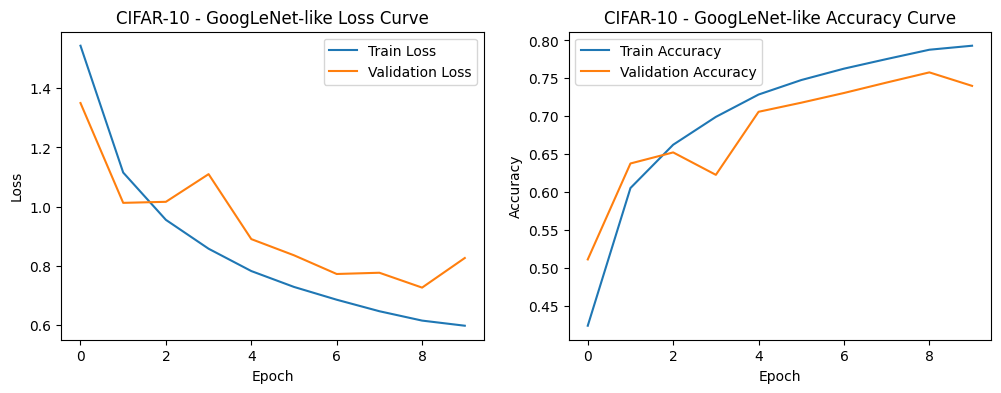

--- Generated Training & Loss/Accuracy curves for GoogLeNet-like on CIFAR-10 ---


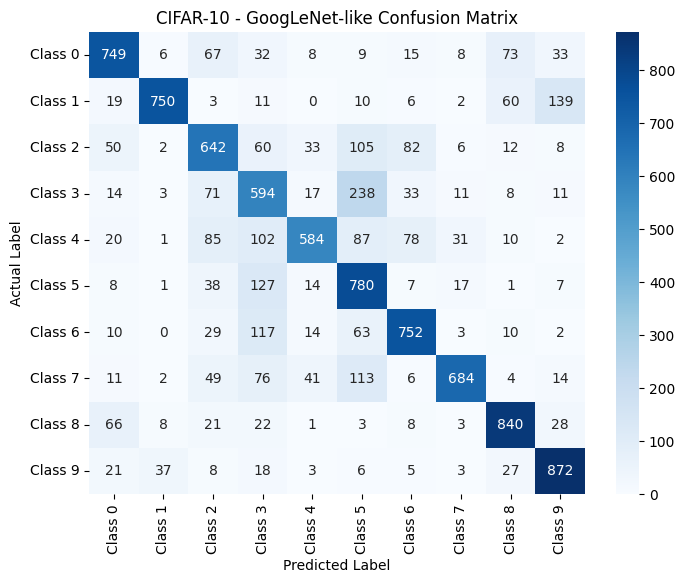

--- Generated Confusion Matrix heatmap for GoogLeNet-like on CIFAR-10 ---


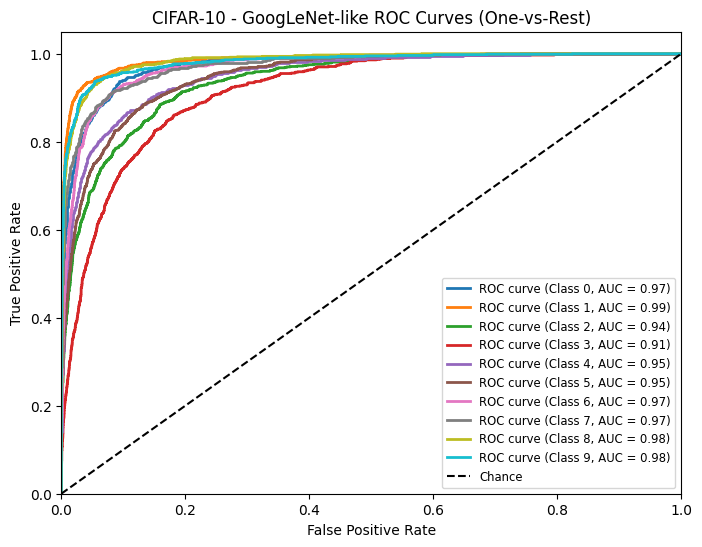

--- Generated ROC curve and AUC for GoogLeNet-like on CIFAR-10 ---

   VISUALIZING BEST MNIST MODEL


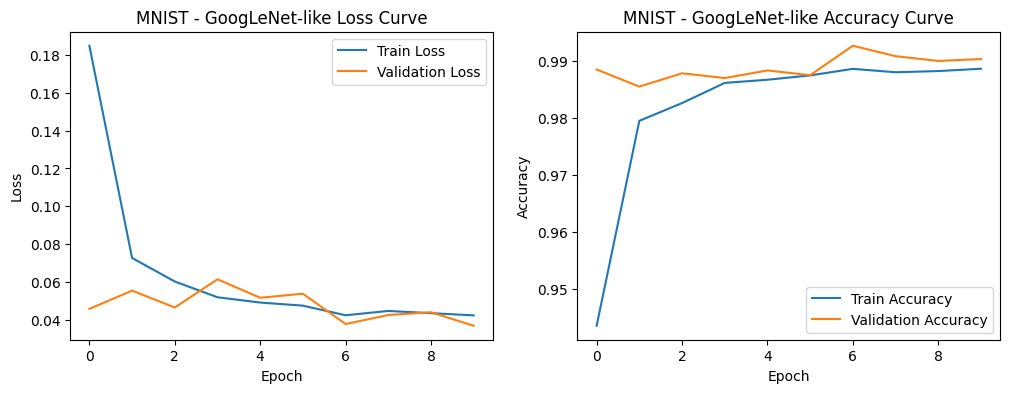

--- Generated Training & Loss/Accuracy curves for GoogLeNet-like on MNIST ---


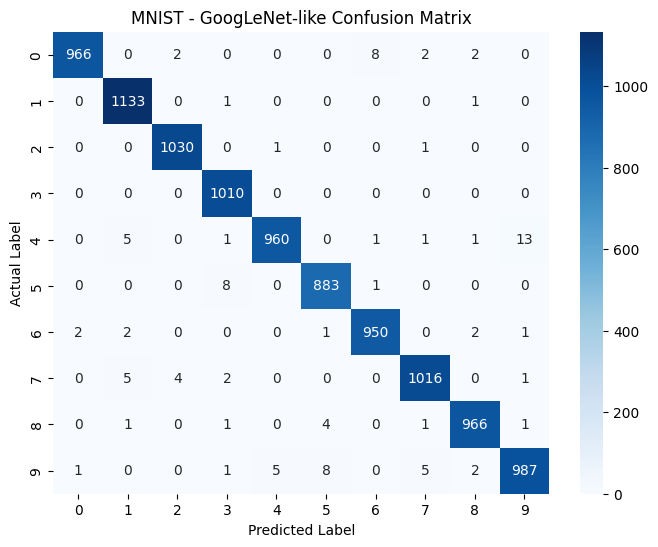

--- Generated Confusion Matrix heatmap for GoogLeNet-like on MNIST ---


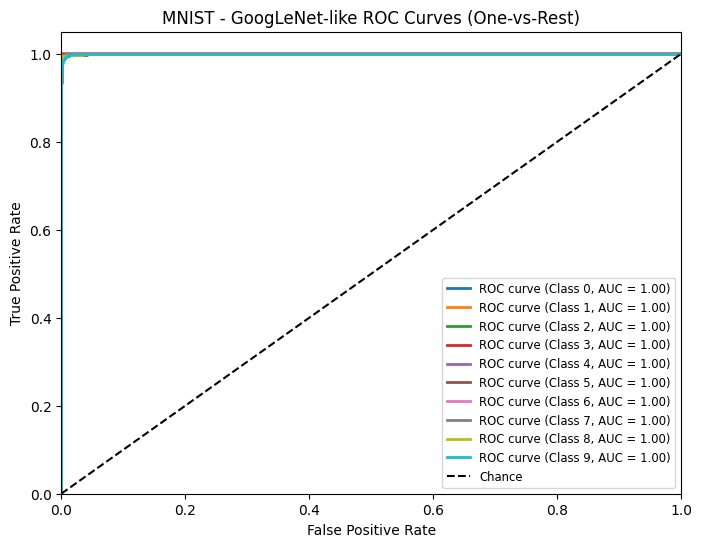

--- Generated ROC curve and AUC for GoogLeNet-like on MNIST ---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import warnings

# Suppress warnings related to Matplotlib/Seaborn
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# ====================================================================
# VISUALIZATION FUNCTIONS
# ====================================================================

def plot_training_history(history, dataset_name, model_name):
    """Generates the training & loss generation curves."""
    plt.figure(figsize=(12, 4))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(f'{dataset_name} - {model_name} Loss Curve')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{dataset_name} - {model_name} Accuracy Curve')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(f"--- Generated Training & Loss/Accuracy curves for {model_name} on {dataset_name} ---")


def plot_confusion_matrix_heatmap(y_true_one_hot, y_pred_probs, class_names, dataset_name, model_name):
    """Generates the confusion matrix heatmap."""
    # Convert one-hot encoded arrays back to single label indices
    y_true_labels = np.argmax(y_true_one_hot, axis=1)
    y_pred_labels = np.argmax(y_pred_probs, axis=1) # Use predicted probabilities

    cm = confusion_matrix(y_true_labels, y_pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{dataset_name} - {model_name} Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print(f"--- Generated Confusion Matrix heatmap for {model_name} on {dataset_name} ---")


def plot_roc_curve_multiclass(y_true_one_hot, y_pred_probs, dataset_name, model_name, num_classes):
    """Generates the multiclass ROC curve (One-vs-Rest)."""
    plt.figure(figsize=(8, 6))

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(num_classes):
        # Calculate ROC curve and AUC for each class vs. the rest
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

        plt.plot(fpr[i], tpr[i],
                 label=f'ROC curve (Class {i}, AUC = {roc_auc[i]:.2f})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{dataset_name} - {model_name} ROC Curves (One-vs-Rest)')
    plt.legend(loc="lower right", fontsize='small')
    plt.show()
    print(f"--- Generated ROC curve and AUC for {model_name} on {dataset_name} ---")


if __name__ == '__main__':
    # NOTE: You must run dl_training_comparison.py first, and ensure the
    # 'cifar_best_data' and 'mnist_best_data' variables are available in this environment
    # (e.g., if you copy-paste the output dictionary or save it to a file).

    # Placeholder for data structure (Assuming data is loaded or available here)
    try:
        if 'cifar_best_data' not in globals() or 'mnist_best_data' not in globals():
            print("ERROR: Please run dl_training_comparison.py first to generate 'cifar_best_data' and 'mnist_best_data'.")
            exit()
    except NameError:
        print("ERROR: Please run dl_training_comparison.py first to generate 'cifar_best_data' and 'mnist_best_data'.")
        exit()


    # 1. Generate plots for CIFAR-10's BEST model
    cifar_best = globals().get('cifar_best_data')
    if cifar_best:
        print("\n" + "="*50)
        print("   VISUALIZING BEST CIFAR-10 MODEL")
        print("="*50)

        plot_training_history(cifar_best['history'], cifar_best['dataset_name'], cifar_best['name'])

        plot_confusion_matrix_heatmap(
            cifar_best['y_test_one_hot'],
            cifar_best['y_pred_probs'],
            cifar_best['class_names'],
            cifar_best['dataset_name'],
            cifar_best['name']
        )

        plot_roc_curve_multiclass(
            cifar_best['y_test_one_hot'],
            cifar_best['y_pred_probs'],
            cifar_best['dataset_name'],
            cifar_best['name'],
            cifar_best['num_classes']
        )

    # 2. Generate plots for MNIST's BEST model
    mnist_best = globals().get('mnist_best_data')
    if mnist_best:
        print("\n" + "="*50)
        print("   VISUALIZING BEST MNIST MODEL")
        print("="*50)

        plot_training_history(mnist_best['history'], mnist_best['dataset_name'], mnist_best['name'])

        plot_confusion_matrix_heatmap(
            mnist_best['y_test_one_hot'],
            mnist_best['y_pred_probs'],
            mnist_best['class_names'],
            mnist_best['dataset_name'],
            mnist_best['name']
        )

        plot_roc_curve_multiclass(
            mnist_best['y_test_one_hot'],
            mnist_best['y_pred_probs'],
            mnist_best['dataset_name'],
            mnist_best['name'],
            mnist_best['num_classes']
        )


# =========================================================================

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16 # New Import for VGG-16
import numpy as np

# Set a seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ====================================================================
# 1. MODEL DEFINITIONS
# ====================================================================

def create_custom_cnn(input_shape, num_classes):
    """
    Defines the custom CNN architecture used in the previous steps.
    """
    model = Sequential([
        # Initial Convolutional Block
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        MaxPooling2D((2, 2)),

        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Flatten and Dense Layers
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),

        # Output layer
        Dense(num_classes, activation='softmax')
    ], name='Custom_CNN')

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def create_vgg16_transfer_model(input_shape, num_classes):
    """
    Constructs a VGG-16 based model using Transfer Learning.
    The convolutional base is loaded, frozen, and a new dense classifier is added.
    """
    # 1. Load VGG16 Convolutional Base (weights from ImageNet, excluding the top layers)
    # The input_shape is used to adapt the VGG base for smaller images (32x32 or 28x28)
    vgg_base = VGG16(weights='imagenet',
                     include_top=False,
                     input_shape=input_shape)

    # 2. Freeze the convolutional base to retain learned features
    vgg_base.trainable = False

    # 3. Create the new classification head
    x = vgg_base.output
    x = Flatten(name='flatten_new')(x)
    x = Dense(256, activation='relu', name='fc1_new')(x)
    x = Dropout(0.5, name='dropout_new')(x)
    x = Dense(num_classes, activation='softmax', name='predictions')(x)

    # 4. Create the final model
    model = Model(inputs=vgg_base.input, outputs=x, name='VGG16_Transfer')

    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ====================================================================
# 2. DATA LOADING & PREPROCESSING PIPELINE
# ====================================================================

def load_and_preprocess_cifar10():
    """Load CIFAR-10 data, normalize, and one-hot encode."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    # Normalize pixel values
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # Convert labels to one-hot encoding
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    input_shape = x_train.shape[1:]
    return (x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes)

def load_and_preprocess_mnist():
    """Load MNIST data, convert to 3 channels, normalize, and one-hot encode."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # MNIST FIX: Reshape to (samples, 28, 28, 1) and expand to 3 channels for VGG16
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32')
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32')

    # Replicate the single channel 3 times (grayscale -> 3-channel color)
    x_train = np.repeat(x_train, 3, axis=-1)
    x_test = np.repeat(x_test, 3, axis=-1)

    # Normalize pixel values
    x_train = x_train / 255.0
    x_test = x_test / 255.0

    # Convert labels to one-hot encoding
    num_classes = 10
    y_train_one_hot = to_categorical(y_train, num_classes)
    y_test_one_hot = to_categorical(y_test, num_classes)

    input_shape = x_train.shape[1:] # (28, 28, 3)
    return (x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes)

# ====================================================================
# 3. COMPARISON PIPELINE
# ====================================================================

def compare_models(dataset_name, data_loader_func, epochs_cnn, epochs_vgg):
    """Runs the comparison between Custom CNN and VGG16 Transfer on a given dataset."""
    print(f"\n====================================================")
    print(f"       Starting Comparison on {dataset_name}")
    print(f"====================================================")

    # 1. Load Data
    x_train, y_train_one_hot, x_test, y_test_one_hot, input_shape, num_classes = data_loader_func()
    print(f"--- Using FULL {dataset_name} dataset: {len(x_train)} training samples and {len(x_test)} test samples ---")

    results = {}

    # --- Data Augmentation Setup (Used only by Custom CNN on CIFAR-10) ---
    datagen = ImageDataGenerator(
        rotation_range=15, width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True
    )
    if dataset_name == "CIFAR-10":
        datagen.fit(x_train)

    # --- MODEL 1: Custom CNN ---
    print(f"\n--- 1. Training Custom CNN for {dataset_name} ({epochs_cnn} epochs) ---")
    model_cnn = create_custom_cnn(input_shape, num_classes)

    # Only show summary once for the first model (Custom CNN)
    if dataset_name == "CIFAR-10":
        model_cnn.summary()

    if dataset_name == "CIFAR-10":
        # Use data augmentation for CIFAR-10
        model_cnn.fit(datagen.flow(x_train, y_train_one_hot, batch_size=4), # Batch size set to 4
                      steps_per_epoch=len(x_train) // 4,
                      epochs=epochs_cnn,
                      validation_data=(x_test, y_test_one_hot),
                      verbose=1)
    else:
        # Simple fit for MNIST
        model_cnn.fit(x_train, y_train_one_hot,
                      batch_size=4, # Batch size set to 4
                      epochs=epochs_cnn,
                      validation_split=0.1,
                      verbose=1)

    loss_cnn, accuracy_cnn = model_cnn.evaluate(x_test, y_test_one_hot, verbose=0)
    results['Custom CNN'] = {'Loss': loss_cnn, 'Accuracy': accuracy_cnn}
    del model_cnn # Clear model from memory

    # --- MODEL 2: VGG16 Transfer Learning ---
    print(f"\n--- 2. Training VGG16 Transfer Model for {dataset_name} ({epochs_vgg} epochs) ---")
    model_vgg = create_vgg16_transfer_model(input_shape, num_classes)
    # Print VGG summary for comparison
    model_vgg.summary()

    # For transfer learning, we can use fewer epochs as the weights are mostly pre-trained
    model_vgg.fit(x_train, y_train_one_hot,
                  batch_size=4, # Batch size set to 4
                  epochs=epochs_vgg,
                  validation_split=0.1,
                  verbose=1)

    loss_vgg, accuracy_vgg = model_vgg.evaluate(x_test, y_test_one_hot, verbose=0)
    results['VGG16 Transfer'] = {'Loss': loss_vgg, 'Accuracy': accuracy_vgg}

    # --- 3. Display Comparison ---
    print("\n----------------------------------------------------")
    print(f"      FINAL PERFORMANCE COMPARISON: {dataset_name}")
    print("----------------------------------------------------")
    print(f"{'Model':<20} | {'Test Loss':<10} | {'Test Accuracy':<15}")
    print("-" * 50)
    for model_name, metrics in results.items():
        print(f"{model_name:<20} | {metrics['Loss']:.4f} | {metrics['Accuracy']:.4f}")
    print("----------------------------------------------------")
    print("====================================================")


if __name__ == '__main__':
    # CIFAR-10 requires more epochs due to its complexity
    compare_models("CIFAR-10", load_and_preprocess_cifar10, epochs_cnn=10, epochs_vgg=10) # Epochs set to 10

    # MNIST is simpler and converges faster
    compare_models("MNIST", load_and_preprocess_mnist, epochs_cnn=10, epochs_vgg=10) # Epochs set to 10



       Starting Comparison on CIFAR-10
--- Using FULL CIFAR-10 dataset: 50000 training samples and 10000 test samples ---

--- 1. Training Custom CNN for CIFAR-10 (10 epochs) ---


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

...

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 62s 5ms/step - accuracy: 0.4201 - loss: 1.6469 - val_accuracy: 0.5466 - val_loss: 1.2932
Epoch 2/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5113 - loss: 1.3897 - val_accuracy: 0.5696 - val_loss: 1.2165
Epoch 3/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 82s 5ms/step - accuracy: 0.5336 - loss: 1.3386 - val_accuracy: 0.5790 - val_loss: 1.2141
Epoch 4/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5423 - loss: 1.3061 - val_accuracy: 0.5838 - val_loss: 1.1950
Epoch 5/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5492 - loss: 1.2847 - val_accuracy: 0.5900 - val_loss: 1.1877
Epoch 6/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5562 - loss: 1.2710 - val_accuracy: 0.5992 - val_loss: 1.1655
Epoch 7/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 0.5620 - loss: 1.2578 - val_accuracy: 0.5988 - val_loss: 1.1629
Epoch 8/10
11250/11250 ━━━━━━━━━━━━━━━━━━━━ 57s 5ms/step - accuracy: 

KeyboardInterrupt: 

In [ ]:
# --------------------------------------------------
# 1. Data Preparation
# --------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.exceptions import UndefinedMetricWarning
import warnings
from hmmlearn import hmm
import numpy as np

# --- Step 1: Discretize continuous features ---
# This turns continuous floats into integers (0..n_bins-1)
discretizer = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_binned = discretizer.fit_transform(X).astype(int)

# --- Step 2: Split data ---
X_train, X_test, y_train, y_test = train_test_split(X_binned, y, test_size=0.20, random_state=42)

# --- Step 3: One-hot encode (for count representation) ---
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_oh = enc.fit_transform(X_train).astype(int)
X_test_oh = enc.transform(X_test).astype(int)

# Each sequence is one continuous sequence
lengths_train = [len(X_train_oh)]

# --------------------------------------------------
# 2. Model Definition and Training
# --------------------------------------------------
classifier = hmm.MultinomialHMM(
    n_components=3,      # tune between 2–8
    n_iter=500,
    tol=1e-4,
    random_state=42
)
classifier.n_features = X_train_oh.shape[1]
classifier.fit(X_train_oh, lengths_train)

# --------------------------------------------------
# 3. Suppress Warnings
# --------------------------------------------------
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
warnings.filterwarnings("ignore")

# --------------------------------------------------
# 4. Prediction and Evaluation
# --------------------------------------------------
y_pred = classifier.predict(X_test_oh)

# Map labels to numeric
y_test_numeric = y_test.replace({'g': 0, 'b': 1})

print("Confusion Matrix:")
print(confusion_matrix(y_test_numeric, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test_numeric, y_pred))


https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


Confusion Matrix:
[[ 0  0 43]
 [ 1  0 27]
 [ 0  0  0]]
--------------------------------------------------
--------------------------------------------------
Performance Evaluation:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      43.0
           1       0.00      0.00      0.00      28.0
           2       0.00      0.00      0.00       0.0

    accuracy                           0.00      71.0
   macro avg       0.00      0.00      0.00      71.0
weighted avg       0.00      0.00      0.00      71.0



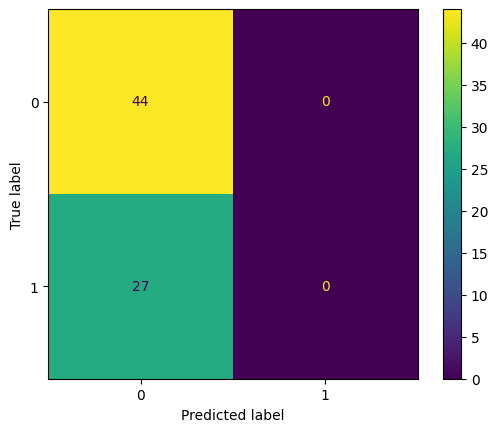

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test_numeric, y_pred)

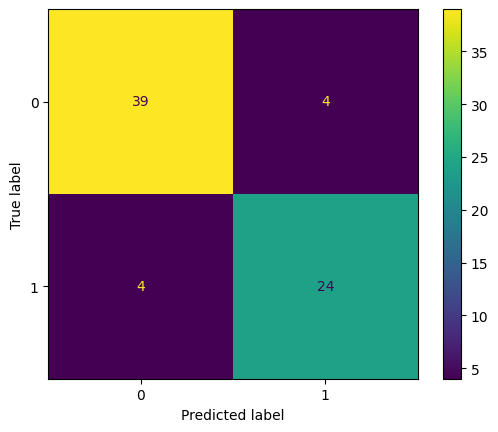

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test_numeric, y_pred)

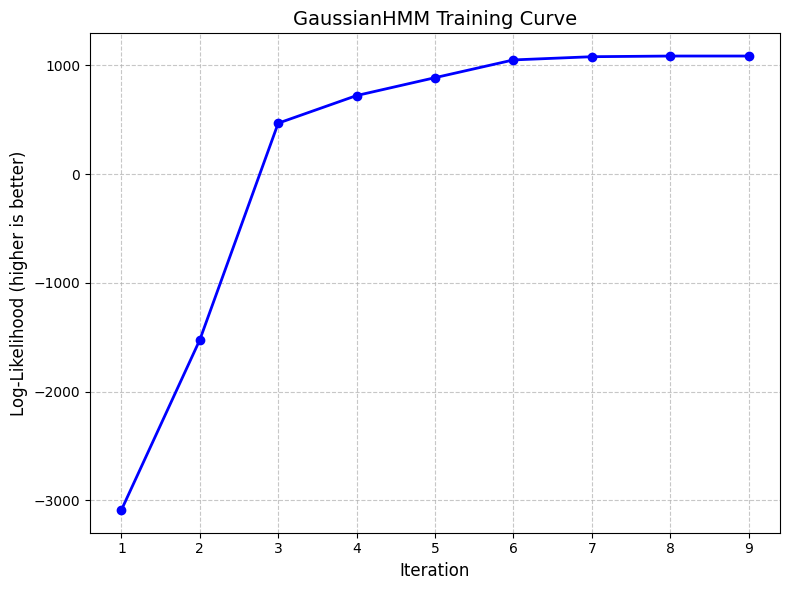

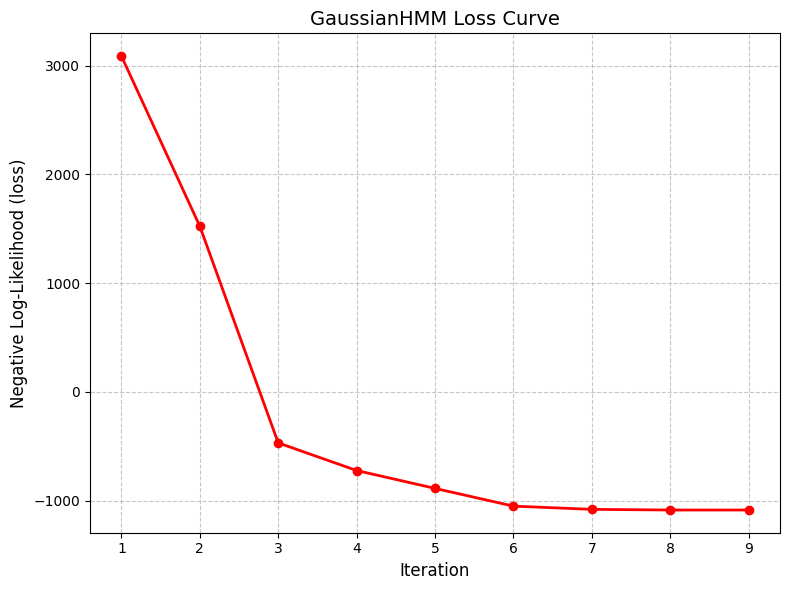

In [ ]:
# 4. Capture Training Log-Likelihoods
# -------------------------------
log_likelihoods = classifier.monitor_.history

# 6. Plot Training & Loss Curves
# -------------------------------
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(log_likelihoods) + 1), log_likelihoods, marker='o', color="blue", linewidth=2)
plt.title("GaussianHMM Training Curve", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Log-Likelihood (higher is better)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Loss curve (negative log-likelihood)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(log_likelihoods) + 1), -np.array(log_likelihoods), marker='o', color="red", linewidth=2)
plt.title("GaussianHMM Loss Curve", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Negative Log-Likelihood (loss)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


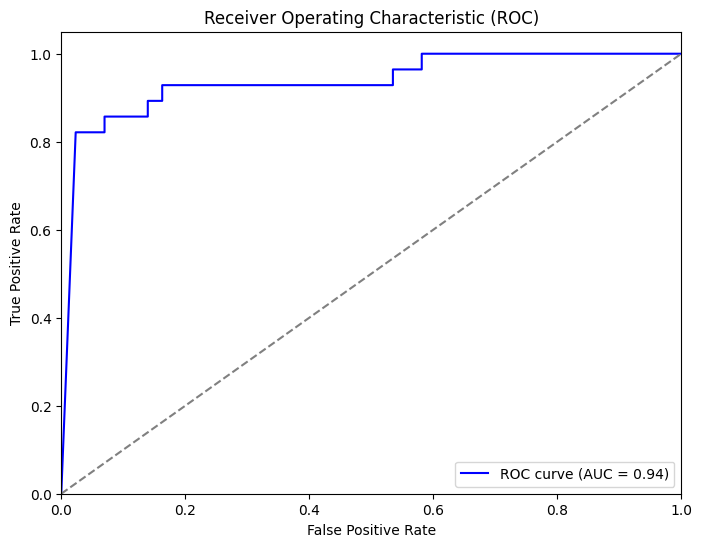

AUC: 0.94


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# Predict probabilities for the test set
y_probs = classifier.predict_proba(X_test)[:, 1]  # Probabilities for the second state (class '1')

# Convert y_test to binary labels if not already (you did this step before)
lb = LabelBinarizer()
y_test_binary = lb.fit_transform(y_test_numeric).ravel()  # Flatten the result to match the shape

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_probs)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Print AUC value
print(f"AUC: {roc_auc:.2f}")


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

from hmmlearn import hmm
classifier = hmm.MultinomialHMM()
classifier.fit(X_train)

y_pred = classifier.predict(X_test)

# Convert y_test labels to numerical format
y_test_numeric = y_test.replace({'B': 0, 'M': 1}) # Assuming 'g' maps to 0 and 'b' to 1 based on the error message


# Evaluation of Classifier Performance
from sklearn.metrics import classification_report, confusion_matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_numeric, y_pred))

print("--------------------------------------------------")
print("--------------------------------------------------")
print("Performance Evaluation:")
print(classification_report(y_test_numeric, y_pred))

https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340


ValueError: Symbol counts should be nonnegative integers